<a href="https://colab.research.google.com/github/Inderjeet-singh01/Shine-Dezign/blob/main/SpamMailDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Spam Mails Detection Model

* User can enter email to check Ham or Spam

* Used various ML alg to make this model



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/1st/Spam Mail Detection/spam.csv")
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [ ]:
df.rename(columns = {'Category': 'Target', 'Message': 'Mail'}, inplace = True)
df.head()

,Target,Mail
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
# Converting ham=0 , spam=1 using Label Encoder

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df['Target'] = encoder.fit_transform(df['Target'])
df.head()

,Target,Mail
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df.isnull().sum()


,0
Target,0
Mail,0


In [ ]:
df.shape

(5572, 2)

In [ ]:
#Checking Duplicates
df.duplicated().sum()

np.int64(415)

In [ ]:
# Removing Duplicates
df = df.drop_duplicates(keep = 'first')

In [ ]:
# Shape after removing Duplicate
df.shape

(5157, 2)

In [ ]:
# Checking percentage of ham(0) and spam(1)

values = df['Target'].value_counts()
total = values.sum()

percentage_0 = (values[0] /total) * 100
percentage_1 = (values[1]/ total) *100

print('percentage of ham(0) :' ,percentage_0)
print('percentage of spam(1) :' ,percentage_1)

percentage of ham(0) : 87.5702928058949
percentage of spam(1) : 12.429707194105099


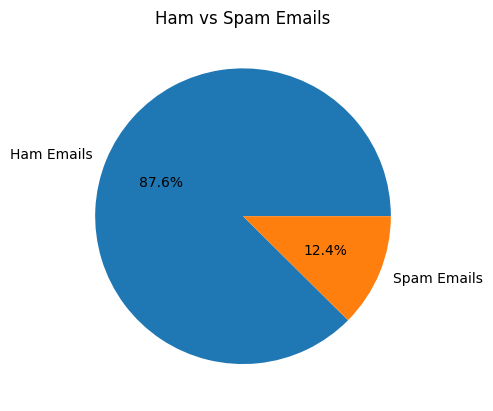

In [ ]:
# Pie Chart

sizes = [percentage_0, percentage_1]
labels = ['Ham Emails', 'Spam Emails']

plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title("Ham vs Spam Emails")
plt.show()

In [ ]:
# Importing NLTK for natural language processing
import nltk
from nltk.corpus import stopwords    # For stopwords

# Importing the Porter Stemmer for EMail stemming
from nltk.stem import SnowballStemmer

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
# Importing the string module for handling special characters

ss = SnowballStemmer('english')

def transform_mails(text):
  text= text.lower()      #Lowercase
  text= nltk.word_tokenize(text)    #Conveerted to tokens


  # Removing special characters
  y = []

  for i in text:
    if i.isalnum():
      y.append(i)


  # Shallow copy of y in text
  text= y[:]
  y.clear()

  for i in text:
    if i not in stopwords.words('english'):  #removing stopwords
      y.append(i)

  # Stemming using Porter stemmer
  text = y[:]
  y.clear()

  for i in text:
    y.append(ss.stem(i))


  # Join the processed tokens back into a single string
  return " ".join(y)

In [ ]:
# Testing transformed_mail function

transform_mails("'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'")

'jurong point crazi avail bugi n great world la e buffet cine got amor wat'

In [ ]:
# Applying transform_mail() function on Mail column of dataset

df['transformed_mails'] = df['Mail'].apply(transform_mails)
df.head()

,Target,Mail,transformed_mails
0,0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entri 2 wkli comp win fa cup final tkts 2...
3,0,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though


In [ ]:
# Converting Text to Vectors

from sklearn.feature_extraction.text import TfidfVectorizer
tfid = TfidfVectorizer(max_features = 3000)

# Dependent & Independent feature
x = tfid.fit_transform(df['transformed_mails'])
y = df['Target'].values

In [ ]:
# Splitting Data
from sklearn.model_selection import train_test_split
x_train, x_test , y_train, y_test = train_test_split(x,y,test_size = 0.20, random_state = 2)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [ ]:
svc = SVC(kernel= "sigmoid", gamma  = 1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth = 5)
lrc = LogisticRegression(solver = 'liblinear', penalty = 'l1')
rfc = RandomForestClassifier(n_estimators = 50, random_state = 2 )
abc = AdaBoostClassifier(n_estimators = 50, random_state = 2)
bc = BaggingClassifier(n_estimators = 50, random_state = 2)
gbdt = GradientBoostingClassifier(n_estimators = 50, random_state = 2)
xgb  = XGBClassifier(n_estimators = 50, random_state = 2)

In [ ]:
models = {
    'SVC': svc,
    'KNeighbors Classifier': knc,
    'Multinomial Naive Bayes': mnb,
    'Decision Tree Classifier': dtc,
    'Logistic Regression': lrc,
    'Random Forest Classifier': rfc,
    'Ada Boost Classifier': abc,
    'Bagging Classifier': bc,
    'Gradient Boosting Classifier': gbdt,
    'XGB Classifier': xgb
    }

In [ ]:
# Creating train_classifier() function to train the model

from sklearn.metrics import accuracy_score, precision_score

def train_classifier(models, x_train, y_train, x_test, y_test):
    models.fit(x_train,y_train)
    y_pred = models.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    return models, accuracy , precision     #also returning model so we can save model for further use otherwise it remained trained inside the loop

In [ ]:
model_name=[]
accuracy_scores = []
precision_scores = []

for name, model in models.items():
    model, current_accuracy, current_precision = train_classifier(model, x_train, y_train, x_test, y_test)
    print()
    print("*"*40)
    print("Model Name: ", name)
    print("Accuracy: ", round(current_accuracy * 100, 1),"%")
    print("Precision: ", round(current_precision, 3))
    print("*"*40)

    model_name.append(name)
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

    models[name] = model   # Updated model dictionary with trained model



****************************************
Model Name:  SVC
Accuracy:  97.8 %
Precision:  0.991
****************************************

****************************************
Model Name:  KNeighbors Classifier
Accuracy:  91.2 %
Precision:  1.0
****************************************

****************************************
Model Name:  Multinomial Naive Bayes
Accuracy:  97.3 %
Precision:  1.0
****************************************

****************************************
Model Name:  Decision Tree Classifier
Accuracy:  93.7 %
Precision:  0.83
****************************************

****************************************
Model Name:  Logistic Regression
Accuracy:  95.8 %
Precision:  0.938
****************************************

****************************************
Model Name:  Random Forest Classifier
Accuracy:  97.3 %
Precision:  1.0
****************************************

****************************************
Model Name:  Ada Boost Classifier
Accuracy:  93.0 %
P

In [ ]:
# Adding in new dataframe to store & getting models with highest accuracy
performance_df = pd.DataFrame({
    'Model': model_name,
    'Accuracy': accuracy_scores,
    'Precision': precision_scores
})

# Sorting by Accuracy
performance_df = performance_df.sort_values(by='Accuracy', ascending=False)

performance_df.head()

,Model,Accuracy,Precision
0,SVC,0.977713,0.990566
2,Multinomial Naive Bayes,0.972868,1.000000
5,Random Forest Classifier,0.972868,1.000000
9,XGB Classifier,0.971899,0.945455
7,Bagging Classifier,0.962209,0.892857


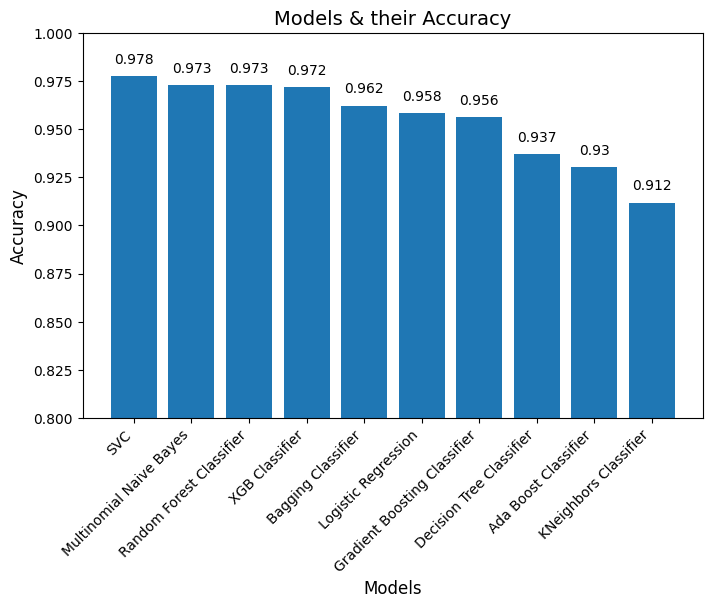

In [ ]:
# Bar graph banana
plt.figure(figsize=(8, 5))
bars = plt.bar(performance_df['Model'], performance_df['Accuracy'])

plt.ylim(0.8, 1.0)

# Labels aur Title add karna
plt.xlabel('Models', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Models & their Accuracy', fontsize=14)
plt.xticks(rotation=45, ha='right')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, round(yval, 3), va='bottom', ha='center')


plt.show()

In [ ]:
# Highest Accuracy Models

print("\n" + "="*50)
print("*"*13, "BEST PERFORMING MODELS", "*"*13)
print("="*50)
print(performance_df.to_string(index=False))


************* BEST PERFORMING MODELS *************
                       Model  Accuracy  Precision
                         SVC  0.977713   0.990566
     Multinomial Naive Bayes  0.972868   1.000000
    Random Forest Classifier  0.972868   1.000000
              XGB Classifier  0.971899   0.945455
          Bagging Classifier  0.962209   0.892857
         Logistic Regression  0.958333   0.937500
Gradient Boosting Classifier  0.956395   0.976744
    Decision Tree Classifier  0.937016   0.829787
        Ada Boost Classifier  0.930233   0.866667
       KNeighbors Classifier  0.911822   1.000000


In [ ]:
print("*"*50, "\n")
user_mail= input("Enter new EMail : ")   #New mail by user to check spam or not

new_mail = transform_mails(user_mail)    #Cleaning mail

new_transformed_mail = tfid.transform([new_mail])   #converting mail to vector

new_pred = models["Random Forest Classifier"].predict(new_transformed_mail)  #we cant use directly because model save in models dict

if new_pred[0] == 0:
    print("\nThis mail is : Not SPAM ✅")
else:
    print("\nThis mail is : SPAM 🚨")

print()
print("*"*50)


************************************************** 

Enter new EMail : Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text

This mail is : SPAM 🚨

**************************************************
